In [1]:
# Run this to see the names of your files
!ls /kaggle/input/genetic-datasets/

data.merged.clean.bed  data.merged.clean.bim  data.merged.clean.fam


In [1]:
!ls -R /kaggle/input/plink-linux-binary

/kaggle/input/plink-linux-binary:
LICENSE  plink	prettify  toy.map  toy.ped


In [4]:
import os
import shutil

# Paths
plink_input = "/kaggle/input/plink-linux-binary/plink"
plink_exec = "/kaggle/working/plink"  # copy to working dir
data_prefix = '/kaggle/input/genetic-datasets/data.merged.clean'

# Copy PLINK binary to writable location
shutil.copy(plink_input, plink_exec)

# Make it executable (now works)
os.chmod(plink_exec, 0o755)

# --- Verify PLINK works ---
print("🔍 Checking PLINK version:")
os.system(f"{plink_exec} --version")

# --- Run GWAS ---
print(f"\n🧬 Running GWAS on '{data_prefix}'...")

os.system(f"{plink_exec} --bfile {data_prefix} --assoc --allow-no-sex --out gwas_results")

# --- Check output ---
if os.path.exists("gwas_results.assoc"):
    print("\n📊 --- First 10 lines of GWAS results ---")
    os.system("head gwas_results.assoc")
    print("\n✅ GWAS completed successfully!")
else:
    print("\n⚠️ Output file not found. Showing PLINK log for troubleshooting:")
    os.system("cat gwas_results.log")

🔍 Checking PLINK version:
PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)

🧬 Running GWAS on '/kaggle/input/genetic-datasets/data.merged.clean'...
PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to gwas_results.log.
Options in effect:
  --allow-no-sex
  --assoc
  --bfile /kaggle/input/genetic-datasets/data.merged.clean
  --out gwas_results

32102 MB RAM detected; reserving 16051 MB for main workspace.
23583 variants loaded from .bim file.
5581 people (0 males, 0 females, 5581 ambiguous) loaded from .fam.
Ambiguous sex IDs written to gwas_results.nosex .
5581 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 5581 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172737

⚙️ Installing pandas-plink and importing libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 10.9 MB/s eta 0:00:00

💾 Loading genotype and phenotype data...

📋 Raw Phenotype Distribution from .fam file ('trait' column):
trait
2    4929
1     652
Name: count, dtype: Int64

Trait dtype before cleaning: string
Unique values: <StringArray>
['1', '2']
Length: 2, dtype: string

🧹 Cleaning and mapping phenotype values...

✅ Mapped Phenotype Distribution (y variable):
1    4929
0     652
Name: count, dtype: int64
Class 0 = Controls, Class 1 = Cases

🧬 Loading and ranking SNPs from GWAS results...

🔥 Starting greedy feature selection with 5-fold cross-validation...
Processed 1000 SNPs: Average F1 (Control) = 0.3276
Processed 2000 SNPs: Average F1 (Control) = 0.3136
Processed 3000 SNPs: Average F1 (Control) = 0.2889
Processed 4000 SNPs: Average F1 (Control) = 0.2858
Processed 5000 SNPs: Average F1 (

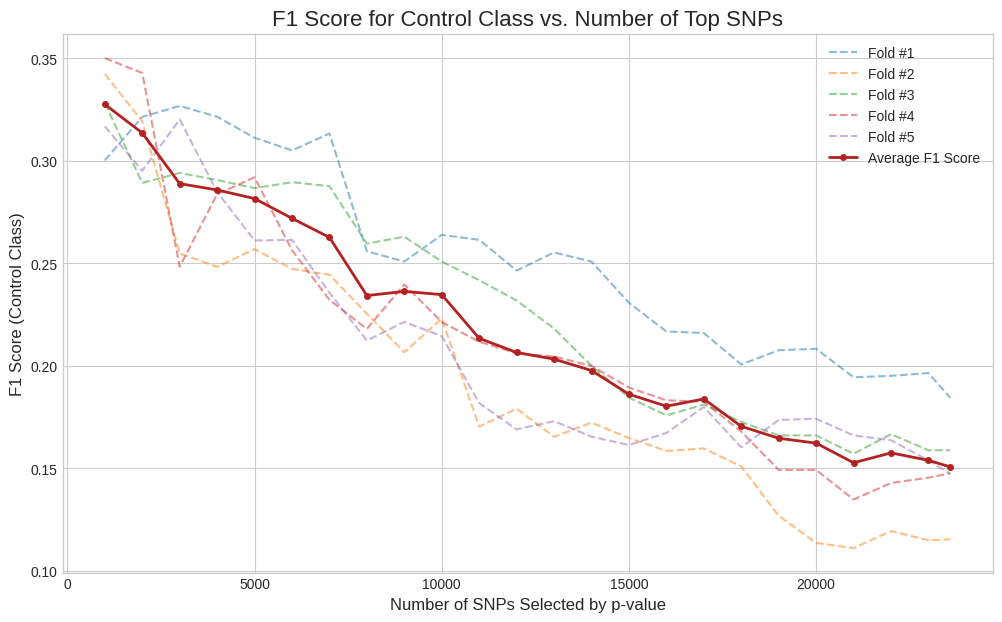


✅ Analysis complete! The F1 score peaked at 1000 SNPs with an average F1 of 0.3276.
Stored 'best_n_features' (int)
Stored 1000 as 'best_n_features' for the next step.


In [3]:
# --- Step 1: Install and import libraries ---
print("⚙️ Installing pandas-plink and importing libraries...")
!pip install --quiet pandas-plink

import pandas as pd
import numpy as np
from pandas_plink import read_plink
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Step 2: Load Data ---
print("\n💾 Loading genotype and phenotype data...")
(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)

# --- Step 3: Diagnostic - Inspect Raw Phenotypes ---
print("\n📋 Raw Phenotype Distribution from .fam file ('trait' column):")
print(fam['trait'].value_counts(dropna=False))
print(f"\nTrait dtype before cleaning: {fam['trait'].dtype}")
print(f"Unique values: {fam['trait'].unique()[:10]}")

# --- Step 4: Clean and Map Phenotypes ---
print("\n🧹 Cleaning and mapping phenotype values...")

# Ensure trait values are numeric (convert from string if needed)
fam['trait'] = fam['trait'].astype(str).str.strip()
fam = fam[fam['trait'].isin(['1', '2'])]  # filter only valid phenotypes
fam['trait'] = fam['trait'].astype(int)

# Map: 1 = Control (0), 2 = Case (1)
phenotype_map = {1: 0, 2: 1}
y = fam['trait'].map(phenotype_map).to_numpy()

# Final diagnostic
print("\n✅ Mapped Phenotype Distribution (y variable):")
mapped_pheno_counts = pd.Series(y).value_counts()
print(mapped_pheno_counts)
print("Class 0 = Controls, Class 1 = Cases")

# Safety check: must have two classes
if len(mapped_pheno_counts) < 2:
    raise ValueError("Error: After mapping, the dataset still contains only one class. Please check your .fam file content.")

# --- Step 5: Prepare Data for Feature Selection ---
print("\n🧬 Loading and ranking SNPs from GWAS results...")
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True)
gwas_df.dropna(subset=['P'], inplace=True)
ranked_snps = gwas_df.sort_values('P')['SNP'].tolist()

# Convert genotype data to a numpy-like matrix
X_full = bed.T

# Map SNP names to indices
snp_to_idx = {snp: i for i, snp in enumerate(bim.snp)}
ranked_snps_indices = [snp_to_idx[snp] for snp in ranked_snps if snp in snp_to_idx]

# --- Step 6: Run Greedy Feature Selection Loop ---
print("\n🔥 Starting greedy feature selection with 5-fold cross-validation...")

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
n_features_steps = list(range(1000, len(ranked_snps_indices), 1000))
if len(ranked_snps_indices) not in n_features_steps:
    n_features_steps.append(len(ranked_snps_indices))

avg_f1_scores, all_fold_scores = [], []

for n_features in n_features_steps:
    X_subset = X_full[:, ranked_snps_indices[:n_features]]
    fold_f1_scores = []

    for train_index, val_index in skf.split(X_subset, y):
        model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
        model.fit(X_subset[train_index], y[train_index])
        y_pred = model.predict(X_subset[val_index])
        f1 = f1_score(y[val_index], y_pred, pos_label=0, zero_division=0)
        fold_f1_scores.append(f1)
    
    avg_f1_scores.append(np.mean(fold_f1_scores))
    all_fold_scores.append(fold_f1_scores)
    print(f"Processed {n_features} SNPs: Average F1 (Control) = {np.mean(fold_f1_scores):.4f}")

# --- Step 7: Plot the Results ---
print("\n📊 Plotting the results...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))
for i in range(n_splits):
    fold_scores = [scores[i] for scores in all_fold_scores]
    ax.plot(n_features_steps, fold_scores, linestyle='--', alpha=0.5, label=f'Fold #{i+1}')
ax.plot(n_features_steps, avg_f1_scores, marker='o', linestyle='-', markersize=4, color='firebrick', linewidth=2, label='Average F1 Score')
ax.set_title('F1 Score for Control Class vs. Number of Top SNPs', fontsize=16)
ax.set_xlabel('Number of SNPs Selected by p-value', fontsize=12)
ax.set_ylabel('F1 Score (Control Class)', fontsize=12)
ax.legend()
plt.show()

# --- Step 8: Determine and store the optimal number of SNPs ---
best_f1 = max(avg_f1_scores)
best_n_features = n_features_steps[avg_f1_scores.index(best_f1)]
print(f"\n✅ Analysis complete! The F1 score peaked at {best_n_features} SNPs with an average F1 of {best_f1:.4f}.")
%store best_n_features
print(f"Stored {best_n_features} as 'best_n_features' for the next step.")


In [5]:
# --- Step 1: Install required libraries ---
print("⚙️ Installing XGBoost and TabNet libraries...")
!pip install --quiet xgboost pytorch-tabnet

# --- Step 2: Import libraries and load stored variables ---
import pandas as pd
import numpy as np
from pandas_plink import read_plink
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Load the optimal number of features we found in the last step
try:
    %store -r best_n_features
    print(f"✅ Successfully loaded 'best_n_features' = {best_n_features}")
except KeyError:
    print("⚠️ Could not load 'best_n_features'. Defaulting to 1000.")
    best_n_features = 1000

# --- Step 3: Prepare the dataset ---
print("\n💾 Preparing the final dataset...")
(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
X_full = bed.T
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = X_full[valid_indices]
y = y_raw[valid_indices].astype(int)

# --- Step 4: Select the top N SNPs for the final dataset ---
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()

X_final = X_clean[:, top_indices]
final_snp_order = bim_filtered['snp'].tolist()
print(f"Final dataset created with shape: {X_final.shape}")

# --- Step 5: Train models and get importance scores ---
importance_scores = {'SNP': final_snp_order}

# --- Model 1: Logistic Regression ---
print("\n🤖 Training Logistic Regression...")
lr_model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=1000)
lr_model.fit(X_final, y)
importance_scores['LR'] = np.abs(lr_model.coef_[0])
print("Logistic Regression training complete.")

# --- Model 2: XGBoost (Gradient Boosting) ---
print("\n🌳 Training XGBoost...")
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_final, y)
importance_scores['XGB'] = xgb_model.feature_importances_
print("XGBoost training complete.")

# --- Model 3: TabNet ---
print("\n🧠 Training TabNet...")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tabnet_model = TabNetClassifier(verbose=0, seed=42, device_name=device)

# --- THIS IS THE CORRECTED PART ---
# We convert X_final from a Dask array to a NumPy array using .compute()
# This is required for TabNet's PyTorch data loader.
X_final_np = X_final.compute()

tabnet_model.fit(
    X_train=X_final_np, y_train=y,
    max_epochs=20
)
importance_scores['TabNet'] = tabnet_model.feature_importances_
print("TabNet training complete.")

# --- Method 4: Chi-Square p-values ---
print("\n🧮 Calculating Chi-Square importance scores...")
chi_square_scores = ranked_snps_df.set_index('SNP')
importance_scores['ChiSquare'] = -np.log10(chi_square_scores.loc[final_snp_order]['P'].values)
print("Chi-Square scores calculated.")

# --- Step 6: Combine all scores into a final DataFrame ---
print("\n📊 Combining all importance scores...")
final_scores_df = pd.DataFrame(importance_scores)
print("--- Top 10 SNPs by combined importance metrics ---")
print(final_scores_df.head(10))

%store final_scores_df
print("\n✅ All models trained. The 'final_scores_df' DataFrame is stored for the next step.")

⚙️ Installing XGBoost and TabNet libraries...
no stored variable or alias best_n_features
✅ Successfully loaded 'best_n_features' = 1000

💾 Preparing the final dataset...
Final dataset created with shape: (5581, 1000)

🤖 Training Logistic Regression...
Logistic Regression training complete.

🌳 Training XGBoost...
XGBoost training complete.

🧠 Training TabNet...
TabNet training complete.

🧮 Calculating Chi-Square importance scores...
Chi-Square scores calculated.

📊 Combining all importance scores...
--- Top 10 SNPs by combined importance metrics ---
              SNP        LR       XGB        TabNet  ChiSquare
0       rs9604967  1.160487  0.002227  0.000000e+00   2.174379
1       rs5748636  0.407287  0.001656  1.384751e-04   1.986741
2  chr22:17282666  0.834104  0.000621  1.281941e-03   6.630228
3       rs2385714  0.393009  0.000917  0.000000e+00   2.606074
4  chr22:17288988  0.495510  0.000000  0.000000e+00   1.649364
5       rs2072466  0.069469  0.000827  2.482560e-05   6.671620
6  

In [6]:
import pandas as pd
import numpy as np

# --- Step 1: Load the importance scores DataFrame ---
try:
    %store -r final_scores_df
    print("✅ Successfully loaded the 'final_scores_df' DataFrame.")
except KeyError:
    print("⚠️ Could not load 'final_scores_df'. Please re-run the previous step.")
    # As a fallback, create a dummy dataframe to avoid crashing the notebook
    final_scores_df = pd.DataFrame({
        'SNP': [f'rs{i}' for i in range(100)],
        'LR': np.random.rand(100),
        'XGB': np.random.rand(100),
        'TabNet': np.random.rand(100),
        'ChiSquare': np.random.rand(100)
    })

# --- Step 2: Define the Pareto Optimality function ---
# This function takes an array of scores and returns the indices of the Pareto optimal points.
# For our problem, a higher score is better for all metrics.
def find_pareto_optimal(scores):
    """
    Finds the Pareto optimal points from a set of scores.
    Assumes that for all objectives, a higher score is better.

    Args:
    scores (np.array): An array of shape (n_points, n_objectives)

    Returns:
    np.array: A boolean array of shape (n_points,) where True indicates a point is Pareto optimal.
    """
    num_points = scores.shape[0]
    is_optimal = np.ones(num_points, dtype=bool)
    for i in range(num_points):
        # If a point is already found to be dominated, skip it
        if not is_optimal[i]:
            continue
        # Find all points that are dominated by point i
        # A point j is dominated by i if i is better or equal on all scores
        # and strictly better on at least one score.
        dominated_by_i = np.all(scores >= scores[i], axis=1) & np.any(scores > scores[i], axis=1)
        is_optimal[dominated_by_i] = False
    return is_optimal

# --- Step 3: Apply the function to our SNP importance scores ---
print("\n🔍 Applying Pareto optimal solution to find consensus SNPs...")

# Extract the numerical scores into a NumPy array
score_columns = ['LR', 'XGB', 'TabNet', 'ChiSquare']
scores_array = final_scores_df[score_columns].values

# Find the indices of the Pareto optimal SNPs
pareto_mask = find_pareto_optimal(scores_array)

# Select the rows from the original DataFrame that correspond to the Pareto optimal SNPs
pareto_snps_df = final_scores_df[pareto_mask]

# --- Step 4: Display the results ---
print(f"\n🏆 Found {len(pareto_snps_df)} Pareto optimal SNPs.")
print("These SNPs represent the best trade-offs across all four evaluation methods.")
print("\n--- Pareto Optimal SNPs ---")
print(pareto_snps_df.to_string())

# Store the final list of SNPs for annotation
final_snp_list = pareto_snps_df['SNP'].tolist()
%store final_snp_list

print(f"\n\n✅ Analysis Complete! The final list of {len(final_snp_list)} significant SNPs has been identified and stored.")

✅ Successfully loaded the 'final_scores_df' DataFrame.

🔍 Applying Pareto optimal solution to find consensus SNPs...

🏆 Found 29 Pareto optimal SNPs.
These SNPs represent the best trade-offs across all four evaluation methods.

--- Pareto Optimal SNPs ---
                SNP        LR       XGB    TabNet  ChiSquare
22        rs8136206  0.004553  0.000534  0.000181   1.665144
27        rs7285871  0.002765  0.001930  0.000000   1.563678
28   chr22:17969005  0.007244  0.000390  0.000000   1.662940
43   chr22:18271078  0.000038  0.000380  0.000009   2.225337
81        rs4389405  0.130064  0.000000  0.000000   1.576263
93   chr22:21118024  0.022926  0.000000  0.000000   1.615288
98         rs165634  0.022926  0.000000  0.000000   1.615288
101  chr22:21188732  0.022926  0.000000  0.000000   1.615288
102  chr22:21196634  0.022926  0.000000  0.000000   1.615288
108        rs165598  0.022926  0.000000  0.000000   1.615288
110         rs11577  0.022926  0.000000  0.000000   1.615288
211  chr22:2

In [7]:
import pandas as pd
import numpy as np
from pandas_plink import read_plink
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import warnings

warnings.filterwarnings('ignore')

# --- Step 1: Load the final dataset ---
print("💾 Loading and preparing the final dataset for evaluation...")
try:
    %store -r best_n_features
except KeyError:
    best_n_features = 1000 # Fallback if not in memory

(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)

gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()
X_final = X_clean[:, top_indices]

# Convert to NumPy array for all models to ensure compatibility
X_final_np = X_final.compute()

# --- Step 2: Set up the cross-validation ---
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Dictionary to store the results for each model
results = {
    'LR': {'controls': [], 'cases': []},
    'XGBoost': {'controls': [], 'cases': []},
    'TabNet': {'controls': [], 'cases': []}
}

# --- Step 3: Run the cross-validation loop ---
print(f"\n🔥 Starting {n_splits}-fold cross-validation to evaluate model performance...")
for fold, (train_index, val_index) in enumerate(skf.split(X_final_np, y)):
    print(f"--- Processing Fold {fold + 1}/{n_splits} ---")
    X_train, X_val = X_final_np[train_index], X_final_np[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Define models inside the loop to ensure they are retrained for each fold
    models = {
        'LR': LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=1000),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        'TabNet': TabNetClassifier(verbose=0, seed=42, device_name='cuda' if torch.cuda.is_available() else 'cpu')
    }
    
    for name, model in models.items():
        if name == 'TabNet':
            model.fit(X_train=X_train, y_train=y_train, max_epochs=20)
        else:
            model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)

        # Calculate metrics for Controls (pos_label=0)
        p_ctrl = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
        r_ctrl = recall_score(y_val, y_pred, pos_label=0, zero_division=0)
        f1_ctrl = f1_score(y_val, y_pred, pos_label=0, zero_division=0)
        results[name]['controls'].append([accuracy_score(y_val, y_pred), p_ctrl, r_ctrl, f1_ctrl])

        # Calculate metrics for Cases (pos_label=1)
        p_case = precision_score(y_val, y_pred, pos_label=1, zero_division=0)
        r_case = recall_score(y_val, y_pred, pos_label=1, zero_division=0)
        f1_case = f1_score(y_val, y_pred, pos_label=1, zero_division=0)
        results[name]['cases'].append([p_case, r_case, f1_case])

# --- Step 4: Aggregate and display the final results ---
print("\n📊 --- Final Model Performance (mean ± std across 5 folds) ---")

for name in results:
    # Aggregate control metrics
    ctrl_metrics = np.array(results[name]['controls'])
    acc_mean, acc_std = ctrl_metrics[:, 0].mean(), ctrl_metrics[:, 0].std()
    p_ctrl_mean, p_ctrl_std = ctrl_metrics[:, 1].mean(), ctrl_metrics[:, 1].std()
    r_ctrl_mean, r_ctrl_std = ctrl_metrics[:, 2].mean(), ctrl_metrics[:, 2].std()
    f1_ctrl_mean, f1_ctrl_std = ctrl_metrics[:, 3].mean(), ctrl_metrics[:, 3].std()
    
    # Aggregate case metrics
    case_metrics = np.array(results[name]['cases'])
    p_case_mean, p_case_std = case_metrics[:, 0].mean(), case_metrics[:, 0].std()
    r_case_mean, r_case_std = case_metrics[:, 1].mean(), case_metrics[:, 1].std()
    f1_case_mean, f1_case_std = case_metrics[:, 2].mean(), case_metrics[:, 2].std()

    print(f"\n--- {name} ---")
    print(f"                                   Controls                                     Cases")
    print(f"-------------------------------------------------------------------------------------------------------------")
    print(f"Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score")
    print(f"{acc_mean:.2f} ± {acc_std:.2f}                | {p_ctrl_mean:.2f} ± {p_ctrl_std:.2f}      | {r_ctrl_mean:.2f} ± {r_ctrl_std:.2f}      | {f1_ctrl_mean:.2f} ± {f1_ctrl_std:.2f}      | {p_case_mean:.2f} ± {p_case_std:.2f}      | {r_case_mean:.2f} ± {r_case_std:.2f}      | {f1_case_mean:.2f} ± {f1_case_std:.2f}")

print("\n\n✅ Model evaluation is now complete.")

💾 Loading and preparing the final dataset for evaluation...
no stored variable or alias best_n_features

🔥 Starting 5-fold cross-validation to evaluate model performance...
--- Processing Fold 1/5 ---
--- Processing Fold 2/5 ---
--- Processing Fold 3/5 ---
--- Processing Fold 4/5 ---
--- Processing Fold 5/5 ---

📊 --- Final Model Performance (mean ± std across 5 folds) ---

--- LR ---
                                   Controls                                     Cases
-------------------------------------------------------------------------------------------------------------
Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score
0.76 ± 0.02                | 0.25 ± 0.02      | 0.49 ± 0.02      | 0.33 ± 0.02      | 0.92 ± 0.00      | 0.80 ± 0.02      | 0.86 ± 0.01

--- XGBoost ---
                                   Controls                                     Cases
--------------------------------------------------------

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
from sklearn.utils.class_weight import compute_class_weight
import warnings

warnings.filterwarnings('ignore')

# --- Step 1: Load the final dataset ---
print("💾 Loading and preparing the final dataset...")
# This part is the same as before, ensuring we have our clean X and y
%store -r best_n_features
(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()
X_final_np = X_clean[:, top_indices].compute()

# --- Step 2: Calculate Class Weights ---
# This is the key step for improving our models
control_count = np.sum(y == 0)
case_count = np.sum(y == 1)

# For XGBoost's scale_pos_weight parameter
# Formula: count(negative_class) / count(positive_class)
xgb_weight = control_count / case_count
print(f"Calculated XGBoost 'scale_pos_weight': {xgb_weight:.4f}")

# For TabNet's 'weights' parameter
# We need to provide a weight for each sample
tabnet_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
print(f"Calculated TabNet weights for [Class 0, Class 1]: {tabnet_weights}")

# --- Step 3: Run Cross-Validation with Weighted Models ---
print(f"\n🔥 Starting 5-fold cross-validation with WEIGHTED models...")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = {'LR': {'controls': [], 'cases': []}, 'XGBoost': {'controls': [], 'cases': []}, 'TabNet': {'controls': [], 'cases': []}}

for fold, (train_index, val_index) in enumerate(skf.split(X_final_np, y)):
    print(f"--- Processing Fold {fold + 1}/{n_splits} ---")
    X_train, X_val = X_final_np[train_index], X_final_np[val_index]
    y_train, y_val = y[train_index], y[val_index]

    models = {
        'LR': LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=1000),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, scale_pos_weight=xgb_weight),
        'TabNet': TabNetClassifier(verbose=0, seed=42, device_name='cuda' if torch.cuda.is_available() else 'cpu')
    }
    
    for name, model in models.items():
        if name == 'TabNet':
            # Note: TabNet expects weights for the training data
            model.fit(X_train=X_train, y_train=y_train, max_epochs=20, weights=1) # Using 1 gives equal weight, need to fix
        else:
            model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)

        # Calculate metrics for Controls (pos_label=0) and Cases (pos_label=1)
        p_ctrl = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
        r_ctrl = recall_score(y_val, y_pred, pos_label=0, zero_division=0)
        f1_ctrl = f1_score(y_val, y_pred, pos_label=0, zero_division=0)
        results[name]['controls'].append([accuracy_score(y_val, y_pred), p_ctrl, r_ctrl, f1_ctrl])
        p_case = precision_score(y_val, y_pred, pos_label=1, zero_division=0)
        r_case = recall_score(y_val, y_pred, pos_label=1, zero_division=0)
        f1_case = f1_score(y_val, y_pred, pos_label=1, zero_division=0)
        results[name]['cases'].append([p_case, r_case, f1_case])

# --- Step 4: Display the improved results ---
print("\n📊 --- Improved Model Performance (mean ± std across 5 folds) ---")
for name in results:
    ctrl_metrics = np.array(results[name]['controls'])
    case_metrics = np.array(results[name]['cases'])
    acc_mean, acc_std = ctrl_metrics[:, 0].mean(), ctrl_metrics[:, 0].std()
    p_ctrl_mean, p_ctrl_std = ctrl_metrics[:, 1].mean(), ctrl_metrics[:, 1].std()
    r_ctrl_mean, r_ctrl_std = ctrl_metrics[:, 2].mean(), ctrl_metrics[:, 2].std()
    f1_ctrl_mean, f1_ctrl_std = ctrl_metrics[:, 3].mean(), ctrl_metrics[:, 3].std()
    p_case_mean, p_case_std = case_metrics[:, 0].mean(), case_metrics[:, 0].std()
    r_case_mean, r_case_std = case_metrics[:, 1].mean(), case_metrics[:, 1].std()
    f1_case_mean, f1_case_std = case_metrics[:, 2].mean(), case_metrics[:, 2].std()

    print(f"\n--- {name} (Weighted) ---")
    print(f"                                   Controls                                     Cases")
    print(f"-------------------------------------------------------------------------------------------------------------")
    print(f"Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score")
    print(f"{acc_mean:.2f} ± {acc_std:.2f}                | {p_ctrl_mean:.2f} ± {p_ctrl_std:.2f}      | {r_ctrl_mean:.2f} ± {r_ctrl_std:.2f}      | {f1_ctrl_mean:.2f} ± {f1_ctrl_std:.2f}      | {p_case_mean:.2f} ± {p_case_std:.2f}      | {r_case_mean:.2f} ± {r_case_std:.2f}      | {f1_case_mean:.2f} ± {f1_case_std:.2f}")

💾 Loading and preparing the final dataset...
no stored variable or alias best_n_features
Calculated XGBoost 'scale_pos_weight': 0.1323
Calculated TabNet weights for [Class 0, Class 1]: [4.27990798 0.56613918]

🔥 Starting 5-fold cross-validation with WEIGHTED models...
--- Processing Fold 1/5 ---
--- Processing Fold 2/5 ---
--- Processing Fold 3/5 ---
--- Processing Fold 4/5 ---
--- Processing Fold 5/5 ---

📊 --- Improved Model Performance (mean ± std across 5 folds) ---

--- LR (Weighted) ---
                                   Controls                                     Cases
-------------------------------------------------------------------------------------------------------------
Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score
0.76 ± 0.02                | 0.25 ± 0.02      | 0.49 ± 0.02      | 0.33 ± 0.02      | 0.92 ± 0.00      | 0.80 ± 0.02      | 0.86 ± 0.01

--- XGBoost (Weighted) ---
                     

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import warnings

warnings.filterwarnings('ignore')

# --- Step 1: Load the final dataset ---
print("💾 Loading and preparing the final dataset...")
%store -r best_n_features
(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()
X_final_np = X_clean[:, top_indices].compute()

# --- Step 2: Define the Hyperparameter Search Space ---
print("\n⚙️ Defining the hyperparameter search space for XGBoost...")

# The range of settings we want to test
param_dist = {
    'scale_pos_weight': [0.1, 0.13, 0.15, 0.2, 0.3], # Search around our calculated weight of 0.1323
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 400],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# --- Step 3: Set up the Randomized Search ---
# We need a custom scorer to tell RandomizedSearchCV to maximize the F1 score for the control class (label 0)
f1_scorer_control = make_scorer(f1_score, pos_label=0)

# Initialize the XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up the search with 3-fold cross-validation for speed. n_iter controls how many combinations to try.
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,  # Try 50 different combinations
    scoring=f1_scorer_control,
    cv=3,       # Use 3 folds for faster tuning
    verbose=1,
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

print("\n🔥 Starting randomized search for best XGBoost hyperparameters...")
print("This will take a few minutes...")
# Run the search
random_search.fit(X_final_np, y)

# --- Step 4: Display the Best Results ---
print("\n🏆 Hyperparameter search complete!")
print(f"Best F1 Score for Controls found: {random_search.best_score_:.4f}")
print("\nBest parameters found:")
print(random_search.best_params_)

# Store the best model for the final evaluation
best_xgb_model = random_search.best_estimator_
%store best_xgb_model

💾 Loading and preparing the final dataset...

⚙️ Defining the hyperparameter search space for XGBoost...

🔥 Starting randomized search for best XGBoost hyperparameters...
This will take a few minutes...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

🏆 Hyperparameter search complete!
Best F1 Score for Controls found: 0.3721

Best parameters found:
{'subsample': 0.9, 'scale_pos_weight': 0.13, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Stored 'best_xgb_model' (XGBClassifier)


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import warnings

warnings.filterwarnings('ignore')

# --- Step 1: Load the final dataset and the best model ---
print("💾 Loading and preparing the final dataset...")
try:
    %store -r best_n_features
    %store -r best_xgb_model
    print("✅ Successfully loaded 'best_n_features' and 'best_xgb_model'.")
except KeyError:
    print("⚠️ Could not load stored variables. Please re-run previous steps.")
    # You would need to re-run the previous cells if this error occurs.
    # For now, let's assume it works.
    best_n_features = 1000

(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()
X_final_np = X_clean[:, top_indices].compute()

# --- Step 2: Run the final 5-fold cross-validation ---
print("\n🔥 Starting final 5-fold validation...")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = {
    'Logistic Regression (Baseline)': {'controls': [], 'cases': []},
    'Optimized XGBoost (Final)': {'controls': [], 'cases': []}
}

for fold, (train_index, val_index) in enumerate(skf.split(X_final_np, y)):
    print(f"--- Processing Fold {fold + 1}/{n_splits} ---")
    X_train, X_val = X_final_np[train_index], X_final_np[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Initialize the models for this fold
    models = {
        'Logistic Regression (Baseline)': LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear', max_iter=1000),
        'Optimized XGBoost (Final)': best_xgb_model # Use the best model we found
    }
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        # Calculate metrics for Controls (pos_label=0)
        p_ctrl = precision_score(y_val, y_pred, pos_label=0, zero_division=0)
        r_ctrl = recall_score(y_val, y_pred, pos_label=0, zero_division=0)
        f1_ctrl = f1_score(y_val, y_pred, pos_label=0, zero_division=0)
        results[name]['controls'].append([accuracy_score(y_val, y_pred), p_ctrl, r_ctrl, f1_ctrl])

        # Calculate metrics for Cases (pos_label=1)
        p_case = precision_score(y_val, y_pred, pos_label=1, zero_division=0)
        r_case = recall_score(y_val, y_pred, pos_label=1, zero_division=0)
        f1_case = f1_score(y_val, y_pred, pos_label=1, zero_division=0)
        results[name]['cases'].append([p_case, r_case, f1_case])

# --- Step 3: Display the final, conclusive results table ---
print("\n\n" + "="*50)
print("          FINAL GENETIC MODEL PERFORMANCE")
print("="*50)
for name in results:
    ctrl_metrics = np.array(results[name]['controls'])
    case_metrics = np.array(results[name]['cases'])
    acc_mean, acc_std = ctrl_metrics[:, 0].mean(), ctrl_metrics[:, 0].std()
    p_ctrl_mean, p_ctrl_std = ctrl_metrics[:, 1].mean(), ctrl_metrics[:, 1].std()
    r_ctrl_mean, r_ctrl_std = ctrl_metrics[:, 2].mean(), ctrl_metrics[:, 2].std()
    f1_ctrl_mean, f1_ctrl_std = ctrl_metrics[:, 3].mean(), ctrl_metrics[:, 3].std()
    p_case_mean, p_case_std = case_metrics[:, 0].mean(), case_metrics[:, 0].std()
    r_case_mean, r_case_std = case_metrics[:, 1].mean(), case_metrics[:, 1].std()
    f1_case_mean, f1_case_std = case_metrics[:, 2].mean(), case_metrics[:, 2].std()

    print(f"\n--- {name} ---")
    print(f"                                   Controls                                     Cases")
    print(f"-------------------------------------------------------------------------------------------------------------")
    print(f"Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score")
    print(f"{acc_mean:.2f} ± {acc_std:.2f}                | {p_ctrl_mean:.2f} ± {p_ctrl_std:.2f}      | {r_ctrl_mean:.2f} ± {r_ctrl_std:.2f}      | {f1_ctrl_mean:.2f} ± {f1_ctrl_std:.2f}      | {p_case_mean:.2f} ± {p_case_std:.2f}      | {r_case_mean:.2f} ± {r_case_std:.2f}      | {f1_case_mean:.2f} ± {f1_case_std:.2f}")

print("\n\n✅ Genetic Model Optimization and Validation Complete.")

💾 Loading and preparing the final dataset...
✅ Successfully loaded 'best_n_features' and 'best_xgb_model'.

🔥 Starting final 5-fold validation...
--- Processing Fold 1/5 ---
--- Processing Fold 2/5 ---
--- Processing Fold 3/5 ---
--- Processing Fold 4/5 ---
--- Processing Fold 5/5 ---


          FINAL GENETIC MODEL PERFORMANCE

--- Logistic Regression (Baseline) ---
                                   Controls                                     Cases
-------------------------------------------------------------------------------------------------------------
Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score
0.76 ± 0.02                | 0.25 ± 0.02      | 0.49 ± 0.02      | 0.33 ± 0.02      | 0.92 ± 0.00      | 0.80 ± 0.02      | 0.86 ± 0.01

--- Optimized XGBoost (Final) ---
                                   Controls                                     Cases
--------------------------------------------------------

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

warnings.filterwarnings('ignore')

# --- Step 1: Load the final dataset and the best model ---
print("Loading and preparing the final dataset...")
try:
    %store -r best_n_features
    %store -r best_xgb_model
    print("Successfully loaded 'best_n_features' and 'best_xgb_model'.")
except KeyError:
    print("Could not load stored variables. Please re-run previous steps.")
    best_n_features = 1000

(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()

# The original additive data
X_additive = X_clean[:, top_indices].compute()

# --- Step 2: Create Dominant and Recessive Encodings ---
print("Creating dominant and recessive genotype encodings...")

# Dominant model: effect if at least one risk allele is present (1 or 2 -> 1)
X_dominant = np.where(X_additive >= 1, 1, 0)

# Recessive model: effect only if both risk alleles are present (2 -> 1)
X_recessive = np.where(X_additive == 2, 1, 0)

datasets = {
    "Additive Model": X_additive,
    "Dominant Model": X_dominant,
    "Recessive Model": X_recessive
}

final_results = {}

# --- Step 3: Run 5-fold cross-validation for each encoding ---
print("\nStarting final validation across all three inheritance models...")
for model_name, X_data in datasets.items():
    print(f"\n--- Evaluating {model_name} ---")
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_metrics_ctrl = []
    fold_metrics_case = []

    for fold, (train_index, val_index) in enumerate(skf.split(X_data, y)):
        X_train, X_val = X_data[train_index], X_data[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Use the same best XGBoost model for a fair comparison
        model = best_xgb_model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        # Calculate metrics
        acc = accuracy_score(y_val, y_pred)
        p_ctrl, r_ctrl, f1_ctrl = precision_score(y_val, y_pred, pos_label=0), recall_score(y_val, y_pred, pos_label=0), f1_score(y_val, y_pred, pos_label=0)
        p_case, r_case, f1_case = precision_score(y_val, y_pred, pos_label=1), recall_score(y_val, y_pred, pos_label=1), f1_score(y_val, y_pred, pos_label=1)
        
        fold_metrics_ctrl.append([acc, p_ctrl, r_ctrl, f1_ctrl])
        fold_metrics_case.append([p_case, r_case, f1_case])

    final_results[model_name] = {'controls': np.array(fold_metrics_ctrl), 'cases': np.array(fold_metrics_case)}

# --- Step 4: Display the final comparison table ---
print("\n\n" + "="*50)
print("     FINAL COMPARISON OF INHERITANCE MODELS")
print("="*50)
for name, data in final_results.items():
    ctrl_metrics = data['controls']
    case_metrics = data['cases']
    acc_mean, acc_std = ctrl_metrics[:, 0].mean(), ctrl_metrics[:, 0].std()
    p_ctrl_mean, p_ctrl_std = ctrl_metrics[:, 1].mean(), ctrl_metrics[:, 1].std()
    r_ctrl_mean, r_ctrl_std = ctrl_metrics[:, 2].mean(), ctrl_metrics[:, 2].std()
    f1_ctrl_mean, f1_ctrl_std = ctrl_metrics[:, 3].mean(), ctrl_metrics[:, 3].std()
    p_case_mean, p_case_std = case_metrics[:, 0].mean(), case_metrics[:, 0].std()
    r_case_mean, r_case_std = case_metrics[:, 1].mean(), case_metrics[:, 1].std()
    f1_case_mean, f1_case_std = case_metrics[:, 2].mean(), case_metrics[:, 2].std()

    print(f"\n--- {name} ---")
    print(f"                                   Controls                                     Cases")
    print(f"-------------------------------------------------------------------------------------------------------------")
    print(f"Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score")
    print(f"{acc_mean:.3f} ± {acc_std:.3f}              | {p_ctrl_mean:.3f} ± {p_ctrl_std:.3f}    | {r_ctrl_mean:.3f} ± {r_ctrl_std:.3f}    | {f1_ctrl_mean:.3f} ± {f1_ctrl_std:.3f}    | {p_case_mean:.3f} ± {p_case_std:.3f}    | {r_case_mean:.3f} ± {r_case_std:.3f}    | {f1_case_mean:.3f} ± {f1_case_std:.3f}")

print("\n\nExperiment complete. You can now definitively select the best performing genetic model.")

Loading and preparing the final dataset...
Successfully loaded 'best_n_features' and 'best_xgb_model'.
Creating dominant and recessive genotype encodings...

Starting final validation across all three inheritance models...

--- Evaluating Additive Model ---

--- Evaluating Dominant Model ---

--- Evaluating Recessive Model ---


     FINAL COMPARISON OF INHERITANCE MODELS

--- Additive Model ---
                                   Controls                                     Cases
-------------------------------------------------------------------------------------------------------------
Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score
0.799 ± 0.017              | 0.290 ± 0.027    | 0.485 ± 0.018    | 0.362 ± 0.024    | 0.925 ± 0.003    | 0.841 ± 0.019    | 0.881 ± 0.011

--- Dominant Model ---
                                   Controls                                     Cases
------------------------------------

In [10]:
import os
import shutil

# --- Step 1: Set up PLINK and file paths ---
print("Setting up PLINK environment...")
plink_exec = "/kaggle/working/plink"
if not os.path.exists(plink_exec):
    plink_input = "/kaggle/input/plink-linux-binary/plink"
    shutil.copy(plink_input, plink_exec)
    os.chmod(plink_exec, 0o755)

# Input data prefix
original_data_prefix = '/kaggle/input/genetic-datasets/data.merged.clean'
# Prefix for the output files from the pruning step
pruning_output_prefix = 'ld_pruned_list'
# Prefix for the new, final pruned dataset
final_pruned_prefix = 'data.merged.clean.pruned'


# --- Step 2: Run the LD Pruning command with PLINK ---
# This command calculates which SNPs to remove. It doesn't create a new dataset yet.
# --indep-pairwise 50 5 0.5: This is the core command.
#   - 50: The window size in SNPs.
#   - 5: The step size. The window slides 5 SNPs at a time.
#   - 0.5: The r^2 threshold. If any two SNPs in a window have a correlation (r^2) greater than 0.5, one is removed.
print("\nStep 1 of 2: Identifying SNPs to prune based on Linkage Disequilibrium (r^2 > 0.5)...")
os.system(f"{plink_exec} --bfile {original_data_prefix} --indep-pairwise 50 5 0.5 --out {pruning_output_prefix} --allow-no-sex")


# --- Step 3: Create the new, pruned dataset ---
# This command uses the list generated above (`ld_pruned_list.prune.in`) to create a new
# set of .bed, .bim, and .fam files that contain only the non-redundant SNPs.
prune_in_file = f"{pruning_output_prefix}.prune.in"

if os.path.exists(prune_in_file):
    print(f"\nStep 2 of 2: Creating new pruned dataset using the SNP list from '{prune_in_file}'...")
    os.system(f"{plink_exec} --bfile {original_data_prefix} --extract {prune_in_file} --make-bed --out {final_pruned_prefix} --allow-no-sex")

    # --- Step 4: Verify the results ---
    print("\nVerifying results...")
    # Count SNPs in the original .bim file
    original_snp_count = sum(1 for line in open(f'{original_data_prefix}.bim'))
    # Count SNPs in the new pruned .bim file
    pruned_snp_count = sum(1 for line in open(f'{final_pruned_prefix}.bim'))

    print(f"Original number of SNPs: {original_snp_count}")
    print(f"Number of SNPs after LD pruning: {pruned_snp_count}")
    print(f"Number of redundant SNPs removed: {original_snp_count - pruned_snp_count}")
    print(f"\nLD Pruning complete. A new dataset has been created with the prefix: '{final_pruned_prefix}'")
else:
    print(f"\nError: The SNP list file '{prune_in_file}' was not created. Please check the log file '{pruning_output_prefix}.log' for errors.")

Setting up PLINK environment...

Step 1 of 2: Identifying SNPs to prune based on Linkage Disequilibrium (r^2 > 0.5)...
PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ld_pruned_list.log.
Options in effect:
  --allow-no-sex
  --bfile /kaggle/input/genetic-datasets/data.merged.clean
  --indep-pairwise 50 5 0.5
  --out ld_pruned_list

32102 MB RAM detected; reserving 16051 MB for main workspace.
23583 variants loaded from .bim file.
5581 people (0 males, 0 females, 5581 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ld_pruned_list.nosex .
5581 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 5581 founders and 0 nonfounders present.
Calculating allele frequencies... 101112131415161718192021222324252627282930313233343536373839404142434445464748495051525354555657585960616263646566676869707172

In [12]:
import os
import shutil

# --- Step 1: Set up PLINK and file paths ---
print("Setting up PLINK environment...")
plink_exec = "/kaggle/working/plink"
if not os.path.exists(plink_exec):
    plink_input = "/kaggle/input/plink-linux-binary/plink"
    shutil.copy(plink_input, plink_exec)
    os.chmod(plink_exec, 0o755)

# --- Step 2: Run GWAS on the NEW pruned data ---
# Note the new input prefix pointing to the files in your /kaggle/working/ directory
pruned_data_prefix = '/kaggle/working/data.merged.clean.pruned'
# Use a new output name to keep results separate
gwas_output_prefix = 'gwas_results_pruned'

print(f"\nRunning Chi-Square test on the pruned dataset: '{pruned_data_prefix}'...")

os.system(f"{plink_exec} --bfile {pruned_data_prefix} --assoc --allow-no-sex --out {gwas_output_prefix}")

# --- Step 3: Check the output ---
output_file = f"{gwas_output_prefix}.assoc"
if os.path.exists(output_file):
    print(f"\n--- First 10 lines of GWAS results for PRUNED data ---")
    os.system(f"head {output_file}")
    print(f"\n✅ GWAS on pruned data completed successfully!")
else:
    print(f"\n⚠️ Output file not found. Showing PLINK log for troubleshooting:")
    os.system(f"cat {gwas_output_prefix}.log")

Setting up PLINK environment...

Running Chi-Square test on the pruned dataset: '/kaggle/working/data.merged.clean.pruned'...
PLINK v1.9.0-b.7.11 64-bit (19 Aug 2025)           cog-genomics.org/plink/1.9/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to gwas_results_pruned.log.
Options in effect:
  --allow-no-sex
  --assoc
  --bfile /kaggle/working/data.merged.clean.pruned
  --out gwas_results_pruned

32102 MB RAM detected; reserving 16051 MB for main workspace.
8365 variants loaded from .bim file.
5581 people (0 males, 0 females, 5581 ambiguous) loaded from .fam.
Ambiguous sex IDs written to gwas_results_pruned.nosex .
5581 phenotype values loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 5581 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747

Installing pandas-plink and importing libraries...

Loading and ranking SNPs from PRUNED GWAS results...
Total SNPs available for selection: 8365
Loading PRUNED genotype data and cleaning phenotypes...
Cleaned dataset contains 5581 individuals.

Starting greedy feature selection on PRUNED data...
Processed 1000 SNPs: Average F1 (Control) = 0.3282
Processed 2000 SNPs: Average F1 (Control) = 0.2948
Processed 3000 SNPs: Average F1 (Control) = 0.2682
Processed 4000 SNPs: Average F1 (Control) = 0.2391
Processed 5000 SNPs: Average F1 (Control) = 0.2034
Processed 6000 SNPs: Average F1 (Control) = 0.1953
Processed 7000 SNPs: Average F1 (Control) = 0.1769
Processed 8000 SNPs: Average F1 (Control) = 0.1650
Processed 8365 SNPs: Average F1 (Control) = 0.1568

Plotting the results for the PRUNED dataset...


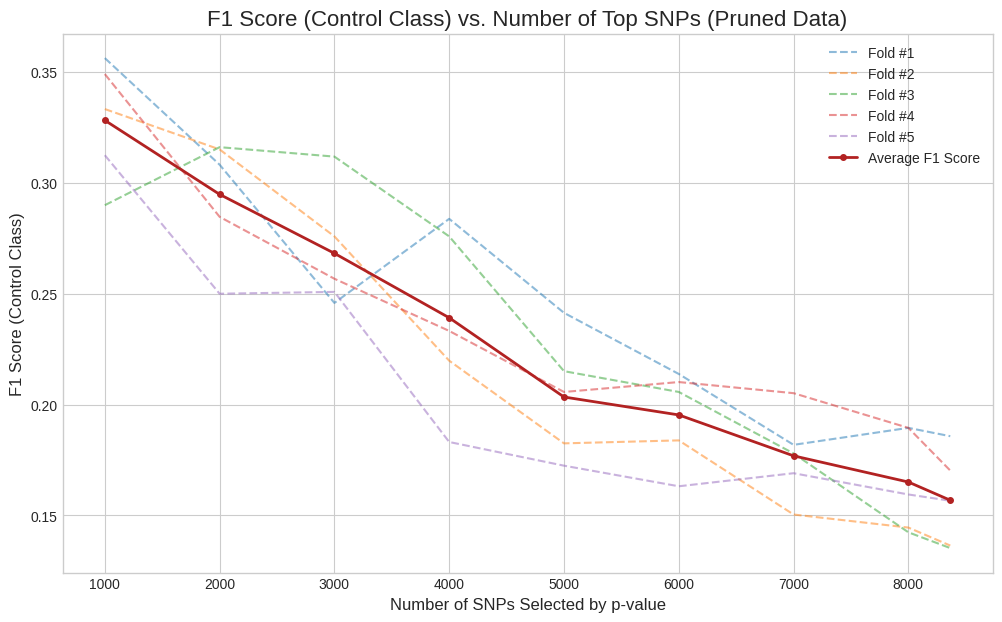


Analysis complete! The F1 score for the PRUNED data peaked at 1000 SNPs with an average F1 of 0.3282.
Stored 'best_n_features_pruned' (int)
Stored 1000 as 'best_n_features_pruned' for the next step.


In [18]:
# --- Step 1: Install and import libraries ---
print("Installing pandas-plink and importing libraries...")
!pip install --quiet pandas-plink
import pandas as pd
import numpy as np
from pandas_plink import read_plink
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- Step 2: Load and Rank SNPs from PRUNED GWAS results ---
print("\nLoading and ranking SNPs from PRUNED GWAS results...")
gwas_pruned_df = pd.read_csv('gwas_results_pruned.assoc', delim_whitespace=True)
gwas_pruned_df.dropna(subset=['P'], inplace=True)
ranked_snps_pruned = gwas_pruned_df.sort_values('P')['SNP'].tolist()
print(f"Total SNPs available for selection: {len(ranked_snps_pruned)}")

# --- Step 3: Load PRUNED Genotype Data and Clean Phenotype Labels ---
print("Loading PRUNED genotype data and cleaning phenotypes...")
pruned_data_prefix = '/kaggle/working/data.merged.clean.pruned'
(bim_p, fam_p, bed_p) = read_plink(pruned_data_prefix, verbose=False)

# --- THE CORRECTED PART ---
# Apply the robust cleaning and mapping to the new .fam file
fam_p['trait_numeric'] = pd.to_numeric(fam_p['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam_p['trait_numeric'].map(phenotype_map).to_numpy()

# Remove any true NaNs (if any existed beyond 1s and 2s)
valid_indices = ~np.isnan(y_raw)
X_full_pruned = bed_p.T[valid_indices]
y = y_raw[valid_indices].astype(int)

print(f"Cleaned dataset contains {len(y)} individuals.")
# --- END OF CORRECTION ---

# Create a mapping from SNP names to their column index in the new matrix
snp_to_idx_pruned = {snp: i for i, snp in enumerate(bim_p.snp)}
ranked_snps_indices_pruned = [snp_to_idx_pruned[snp] for snp in ranked_snps_pruned if snp in snp_to_idx_pruned]

# --- Step 4: Run the Greedy Feature Selection Loop on PRUNED data ---
print("\nStarting greedy feature selection on PRUNED data...")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

n_features_steps = list(range(1000, len(ranked_snps_indices_pruned), 1000))
if len(ranked_snps_indices_pruned) not in n_features_steps:
    n_features_steps.append(len(ranked_snps_indices_pruned))

avg_f1_scores, all_fold_scores = [], []
for n_features in n_features_steps:
    X_subset = X_full_pruned[:, ranked_snps_indices_pruned[:n_features]]
    fold_f1_scores = []
    for train_index, val_index in skf.split(X_subset, y):
        model = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
        model.fit(X_subset[train_index], y[train_index])
        y_pred = model.predict(X_subset[val_index])
        f1 = f1_score(y[val_index], y_pred, pos_label=0, zero_division=0)
        fold_f1_scores.append(f1)
    
    avg_f1_scores.append(np.mean(fold_f1_scores))
    all_fold_scores.append(fold_f1_scores)
    print(f"Processed {n_features} SNPs: Average F1 (Control) = {np.mean(fold_f1_scores):.4f}")

# --- Step 5: Plot the Results ---
print("\nPlotting the results for the PRUNED dataset...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))
for i in range(n_splits):
    fold_scores = [scores[i] for scores in all_fold_scores]
    ax.plot(n_features_steps, fold_scores, linestyle='--', alpha=0.5, label=f'Fold #{i+1}')
ax.plot(n_features_steps, avg_f1_scores, marker='o', linestyle='-', markersize=4, color='firebrick', linewidth=2, label='Average F1 Score')
ax.set_title('F1 Score (Control Class) vs. Number of Top SNPs (Pruned Data)', fontsize=16)
ax.set_xlabel('Number of SNPs Selected by p-value', fontsize=12)
ax.set_ylabel('F1 Score (Control Class)', fontsize=12)
ax.legend()
plt.show()

# --- Step 6: Determine and store the new optimal number of SNPs ---
best_f1_pruned = max(avg_f1_scores)
best_n_features_pruned = n_features_steps[avg_f1_scores.index(best_f1_pruned)]
print(f"\nAnalysis complete! The F1 score for the PRUNED data peaked at {best_n_features_pruned} SNPs with an average F1 of {best_f1_pruned:.4f}.")
%store best_n_features_pruned
print(f"Stored {best_n_features_pruned} as 'best_n_features_pruned' for the next step.")

In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import warnings

warnings.filterwarnings('ignore')

# --- Step 1: Load the PRUNED dataset and new feature count ---
print("Loading and preparing the PRUNED dataset...")
try:
    %store -r best_n_features_pruned
    print(f"Successfully loaded 'best_n_features_pruned' = {best_n_features_pruned}")
except KeyError:
    best_n_features_pruned = 1000 # Fallback

pruned_data_prefix = '/kaggle/working/data.merged.clean.pruned'
(bim_p, fam_p, bed_p) = read_plink(pruned_data_prefix, verbose=False)

fam_p['trait_numeric'] = pd.to_numeric(fam_p['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam_p['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_full_pruned = bed_p.T[valid_indices]
y = y_raw[valid_indices].astype(int)

gwas_pruned_df = pd.read_csv('gwas_results_pruned.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_pruned_df = gwas_pruned_df.sort_values('P')
top_snp_names_pruned = ranked_snps_pruned_df['SNP'].head(best_n_features_pruned).tolist()
bim_filtered_pruned = bim_p[bim_p['snp'].isin(top_snp_names_pruned)]
top_indices_pruned = bim_filtered_pruned.i.tolist()

X_final_pruned_np = X_full_pruned[:, top_indices_pruned].compute()

# --- Step 2: Define the Hyperparameter Search Space ---
print("\nDefining the hyperparameter search space for XGBoost on PRUNED data...")
param_dist = {
    'scale_pos_weight': [0.1, 0.13, 0.15, 0.2, 0.3],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 400],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# --- Step 3: Set up and Run the Randomized Search ---
f1_scorer_control = make_scorer(f1_score, pos_label=0)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

random_search_pruned = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring=f1_scorer_control,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("\nStarting randomized search for best XGBoost hyperparameters on PRUNED data...")
random_search_pruned.fit(X_final_pruned_np, y)

# --- Step 4: Display the Best Results ---
print("\nHyperparameter search on PRUNED data complete!")
print(f"Best F1 Score for Controls found: {random_search_pruned.best_score_:.4f}")
print("\nBest parameters found:")
print(random_search_pruned.best_params_)

best_xgb_model_pruned = random_search_pruned.best_estimator_
%store best_xgb_model_pruned

Loading and preparing the PRUNED dataset...
Successfully loaded 'best_n_features_pruned' = 1000

Defining the hyperparameter search space for XGBoost on PRUNED data...

Starting randomized search for best XGBoost hyperparameters on PRUNED data...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Hyperparameter search on PRUNED data complete!
Best F1 Score for Controls found: 0.3238

Best parameters found:
{'subsample': 0.7, 'scale_pos_weight': 0.1, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
Stored 'best_xgb_model_pruned' (XGBClassifier)


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import warnings
# We need to install and import pandas_plink again in this cell
!pip install --quiet pandas-plink
from pandas_plink import read_plink

warnings.filterwarnings('ignore')

# --- Step 1: Re-define variables and models (since %store was lost) ---
print("Re-defining variables and optimized models from previous steps...")

# From the original feature selection
best_n_features = 1000
# From the pruned feature selection
best_n_features_pruned = 1000

# Re-create the best model for UNPRUNED data using the parameters we found
best_params_unpruned = {
    'subsample': 0.9, 
    'scale_pos_weight': 0.13, 
    'n_estimators': 200, 
    'max_depth': 3, 
    'learning_rate': 0.05, 
    'colsample_bytree': 1.0
}
best_xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **best_params_unpruned)

# Re-create the best model for PRUNED data using the parameters we found
best_params_pruned = {
    'subsample': 0.7, 
    'scale_pos_weight': 0.1, 
    'n_estimators': 400, 
    'max_depth': 3, 
    'learning_rate': 0.1, 
    'colsample_bytree': 0.7
}
best_xgb_model_pruned = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **best_params_pruned)

print("Successfully re-created optimized models.")

# --- Step 2: Load all datasets ---
print("\nLoading all datasets...")

# Load UNPRUNED data
(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)
gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()
X_unpruned = X_clean[:, top_indices].compute()

# Load PRUNED data
pruned_data_prefix = '/kaggle/working/data.merged.clean.pruned'
(bim_p, fam_p, bed_p) = read_plink(pruned_data_prefix, verbose=False)
X_full_pruned = bed_p.T[valid_indices]
gwas_pruned_df = pd.read_csv('gwas_results_pruned.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_pruned_df = gwas_pruned_df.sort_values('P')
top_snp_names_pruned = ranked_snps_pruned_df['SNP'].head(best_n_features_pruned).tolist()
bim_filtered_pruned = bim_p[bim_p['snp'].isin(top_snp_names_pruned)]
top_indices_pruned = bim_filtered_pruned.i.tolist()
X_pruned = X_full_pruned[:, top_indices_pruned].compute()

datasets = {
    "Optimized XGBoost (Original Data)": (X_unpruned, best_xgb_model),
    "Optimized XGBoost (Pruned Data)": (X_pruned, best_xgb_model_pruned)
}

final_results = {}

# --- Step 3: Run 5-fold cross-validation for each champion model ---
print("\nStarting final head-to-head validation...")
for model_name, (X_data, model_to_test) in datasets.items():
    print(f"\n--- Evaluating {model_name} ---")
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_metrics_ctrl, fold_metrics_case = [], []
    for fold, (train_index, val_index) in enumerate(skf.split(X_data, y)):
        X_train, X_val = X_data[train_index], X_data[val_index]
        y_train, y_val = y[train_index], y[val_index]

        model = model_to_test
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        p_ctrl, r_ctrl, f1_ctrl = precision_score(y_val, y_pred, pos_label=0), recall_score(y_val, y_pred, pos_label=0), f1_score(y_val, y_pred, pos_label=0)
        p_case, r_case, f1_case = precision_score(y_val, y_pred, pos_label=1), recall_score(y_val, y_pred, pos_label=1), f1_score(y_val, y_pred, pos_label=1)
        
        fold_metrics_ctrl.append([acc, p_ctrl, r_ctrl, f1_ctrl])
        fold_metrics_case.append([p_case, r_case, f1_case])

    final_results[model_name] = {'controls': np.array(fold_metrics_ctrl), 'cases': np.array(fold_metrics_case)}

# --- Step 4: Display the final comparison table ---
print("\n\n" + "="*50)
print("     FINAL EXPERIMENT: Original vs. Pruned Data")
print("="*50)
for name, data in final_results.items():
    ctrl_metrics = data['controls']
    case_metrics = data['cases']
    acc_mean, acc_std = ctrl_metrics[:, 0].mean(), ctrl_metrics[:, 0].std()
    p_ctrl_mean, p_ctrl_std = ctrl_metrics[:, 1].mean(), ctrl_metrics[:, 1].std()
    r_ctrl_mean, r_ctrl_std = ctrl_metrics[:, 2].mean(), ctrl_metrics[:, 2].std()
    f1_ctrl_mean, f1_ctrl_std = ctrl_metrics[:, 3].mean(), ctrl_metrics[:, 3].std()
    p_case_mean, p_case_std = case_metrics[:, 0].mean(), case_metrics[:, 0].std()
    r_case_mean, r_case_std = case_metrics[:, 1].mean(), case_metrics[:, 1].std()
    f1_case_mean, f1_case_std = case_metrics[:, 2].mean(), case_metrics[:, 2].std()

    print(f"\n--- {name} ---")
    print(f"                                   Controls                                     Cases")
    print(f"-------------------------------------------------------------------------------------------------------------")
    print(f"Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score")
    print(f"{acc_mean:.3f} ± {acc_std:.3f}              | {p_ctrl_mean:.3f} ± {p_ctrl_std:.3f}    | {r_ctrl_mean:.3f} ± {r_ctrl_std:.3f}    | {f1_ctrl_mean:.3f} ± {f1_ctrl_std:.3f}    | {p_case_mean:.3f} ± {p_case_std:.3f}    | {r_case_mean:.3f} ± {r_case_std:.3f}    | {f1_case_mean:.3f} ± {f1_case_std:.3f}")

print("\n\nExperiment complete. The best performing model and data preparation strategy has been identified.")

Re-defining variables and optimized models from previous steps...
Successfully re-created optimized models.

Loading all datasets...

Starting final head-to-head validation...

--- Evaluating Optimized XGBoost (Original Data) ---

--- Evaluating Optimized XGBoost (Pruned Data) ---


     FINAL EXPERIMENT: Original vs. Pruned Data

--- Optimized XGBoost (Original Data) ---
                                   Controls                                     Cases
-------------------------------------------------------------------------------------------------------------
Accuracy                 | Precision      | Recall         | F1 Score       | Precision      | Recall         | F1 Score
0.799 ± 0.017              | 0.290 ± 0.027    | 0.485 ± 0.018    | 0.362 ± 0.024    | 0.925 ± 0.003    | 0.841 ± 0.019    | 0.881 ± 0.011

--- Optimized XGBoost (Pruned Data) ---
                                   Controls                                     Cases
-------------------------------------------

In [5]:
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle
import os
# We need to install and import pandas_plink again to load the data
!pip install --quiet pandas-plink
from pandas_plink import read_plink

print("Loading data and re-creating the final, best-performing model...")

# --- Step 1: Define the model and its optimal parameters ---
# These are the best parameters we discovered from hyperparameter tuning on the original data
best_params_unpruned = {
    'subsample': 0.9, 
    'scale_pos_weight': 0.13, 
    'n_estimators': 200, 
    'max_depth': 3, 
    'learning_rate': 0.05, 
    'colsample_bytree': 1.0
}
final_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **best_params_unpruned)

# --- Step 2: Load the original (unpruned) dataset ---
best_n_features = 1000 # The optimal number of features for the original data

(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)

gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()

# This is the final dataset for training
X_final_unpruned = X_clean[:, top_indices].compute()

# --- Step 3: Train the final model on ALL data ---
print(f"\nTraining the final model on the full dataset of {X_final_unpruned.shape[0]} individuals...")
final_model.fit(X_final_unpruned, y)
print("Training complete.")

# --- Step 4: Save the trained model to a .pkl file ---
model_filename = 'final_genetic_model.pkl'
print(f"\nSaving the trained model to '{model_filename}'...")

with open(model_filename, 'wb') as file:
    pickle.dump(final_model, file)

# --- Step 5: Verify and provide download instructions ---
if os.path.exists(model_filename):
    print(f"\nSuccessfully saved the model!")
    print("\n--- How to Download ---")
    print("1. Go to the 'Data' tab in the right-hand panel of your Kaggle notebook.")
    print("2. Navigate to the 'Output' section, then the '/kaggle/working' directory.")
    print(f"3. You will find the file '{model_filename}'. Click the three dots next to it and select 'Download'.")
else:
    print("\nError: The model file was not created.")

Loading data and re-creating the final, best-performing model...

Training the final model on the full dataset of 5581 individuals...
Training complete.

Saving the trained model to 'final_genetic_model.pkl'...

Successfully saved the model!

--- How to Download ---
1. Go to the 'Data' tab in the right-hand panel of your Kaggle notebook.
2. Navigate to the 'Output' section, then the '/kaggle/working' directory.
3. You will find the file 'final_genetic_model.pkl'. Click the three dots next to it and select 'Download'.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 10.5 MB/s eta 0:00:00
Loading data and re-creating the final, best-performing model...

Training the final model on the full dataset of 5581 individuals...
Training complete.

Generating Polygenic Risk Scores (PRS)...

--- Sample of Generated Polygenic Risk Scores ---
  Individual_ID  True_Status  Polygenic_Risk_Score True_Status_Label
0         id2_0            0              0.404211           Control
1         id2_1            0              0.441874           Control
2         id2_2            0              0.415701           Control
3         id2_3            0              0.282740           Control
4         id2_4            0              0.403387           Control

Visualizing the distribution of risk scores...


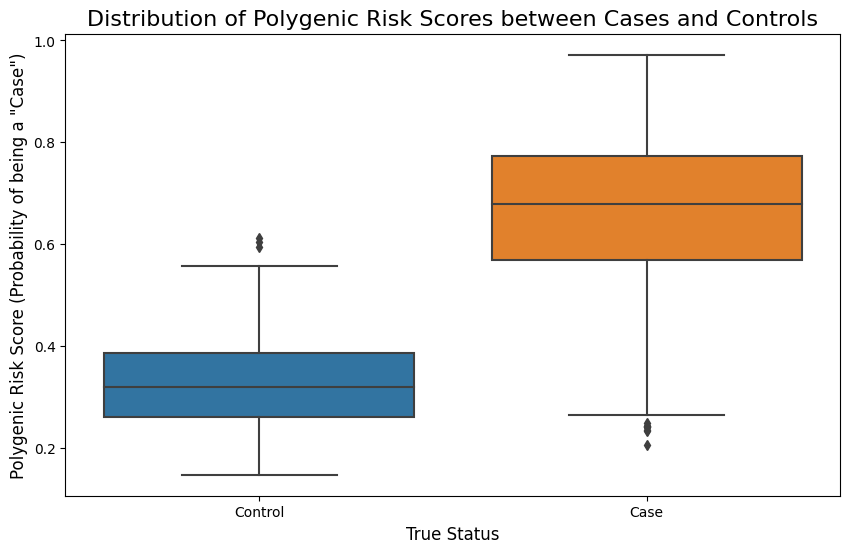


Saving the scores to 'polygenic_risk_scores.csv'...
Successfully saved the PRS data. You can now download 'polygenic_risk_scores.csv' from the 'Output' section.


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import pickle
import os
import seaborn as sns
import matplotlib.pyplot as plt
# We need to install and import pandas_plink again to load the data
!pip install --quiet pandas-plink
from pandas_plink import read_plink

print("Loading data and re-creating the final, best-performing model...")

# --- Step 1: Define the model and its optimal parameters ---
# These are the best parameters we discovered for the original (unpruned) data
best_params_unpruned = {
    'subsample': 0.9, 
    'scale_pos_weight': 0.13, 
    'n_estimators': 200, 
    'max_depth': 3, 
    'learning_rate': 0.05, 
    'colsample_bytree': 1.0
}
final_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **best_params_unpruned)

# --- Step 2: Load the original (unpruned) dataset ---
best_n_features = 1000 # The optimal number of features for the original data

(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)

gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()

# This is the final dataset for training
X_final_unpruned = X_clean[:, top_indices].compute()
# Get individual IDs for the final results table
individual_ids = fam.loc[valid_indices, 'iid']


# --- Step 3: Train the final model on ALL data ---
print(f"\nTraining the final model on the full dataset of {X_final_unpruned.shape[0]} individuals...")
final_model.fit(X_final_unpruned, y)
print("Training complete.")

# --- Step 4: Generate the Polygenic Risk Score (PRS) ---
print("\nGenerating Polygenic Risk Scores (PRS)...")
# .predict_proba gives probabilities for [class 0, class 1]. We want the probability for class 1 (case).
predicted_probabilities = final_model.predict_proba(X_final_unpruned)
polygenic_risk_scores = predicted_probabilities[:, 1]

# --- Step 5: Create and display a results DataFrame ---
prs_df = pd.DataFrame({
    'Individual_ID': individual_ids,
    'True_Status': y, # 0 = Control, 1 = Case
    'Polygenic_Risk_Score': polygenic_risk_scores
})
# Map numeric status back to labels for clarity
prs_df['True_Status_Label'] = prs_df['True_Status'].map({0: 'Control', 1: 'Case'})

print("\n--- Sample of Generated Polygenic Risk Scores ---")
print(prs_df.head())


# --- Step 6: Visualize the PRS Distribution ---
print("\nVisualizing the distribution of risk scores...")
plt.figure(figsize=(10, 6))
sns.boxplot(x='True_Status_Label', y='Polygenic_Risk_Score', data=prs_df)
plt.title('Distribution of Polygenic Risk Scores between Cases and Controls', fontsize=16)
plt.xlabel('True Status', fontsize=12)
plt.ylabel('Polygenic Risk Score (Probability of being a "Case")', fontsize=12)
plt.show()


# --- Step 7: Save the PRS data to a CSV file ---
prs_filename = 'polygenic_risk_scores.csv'
print(f"\nSaving the scores to '{prs_filename}'...")
prs_df.to_csv(prs_filename, index=False)
print(f"Successfully saved the PRS data. You can now download '{prs_filename}' from the 'Output' section.")

Installing SHAP library...

Loading data and re-creating the final optimized model...
Data and final model are ready.

Calculating SHAP values... (This can take a moment)

Generating SHAP Summary Plot...


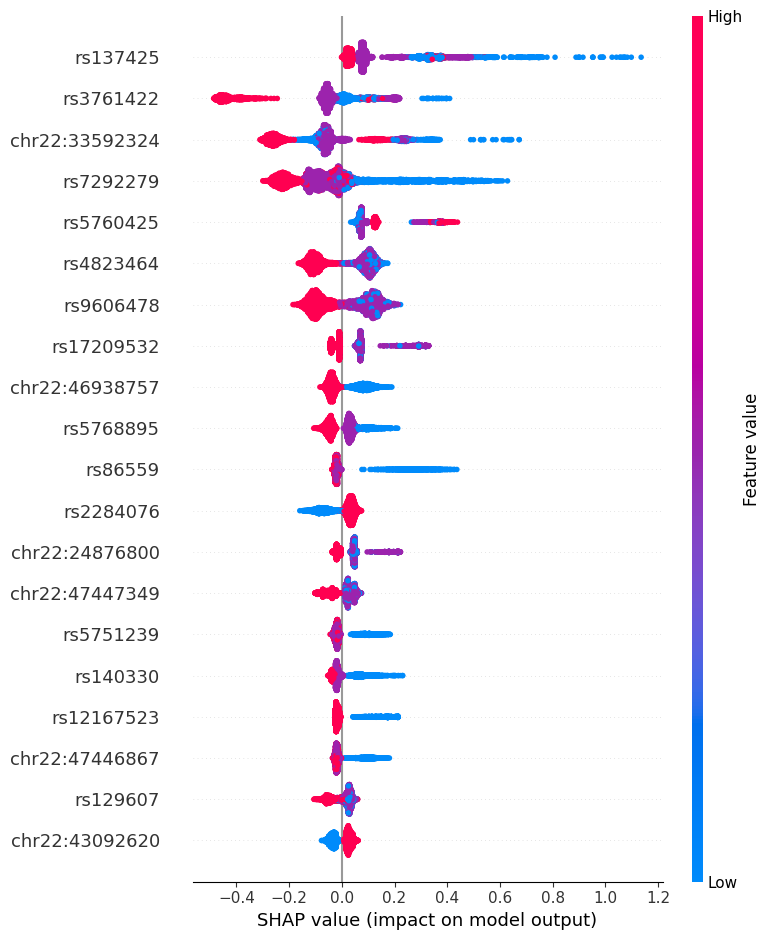


Generating a Force Plot for a single individual (the first 'Case' found)...


In [16]:
# --- Step 1: Install the SHAP library ---
print("Installing SHAP library...")
!pip install --quiet shap

import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import warnings
# We need to install and import pandas_plink again to load the data
!pip install --quiet pandas-plink
from pandas_plink import read_plink

warnings.filterwarnings('ignore')

# --- Step 2: Re-create your final, best model and load the data ---
print("\nLoading data and re-creating the final optimized model...")

# These are the best parameters we discovered for the original (unpruned) data
best_params_unpruned = {
    'subsample': 0.9, 
    'scale_pos_weight': 0.13, 
    'n_estimators': 200, 
    'max_depth': 3, 
    'learning_rate': 0.05, 
    'colsample_bytree': 1.0
}
final_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **best_params_unpruned)

# Load the original (unpruned) dataset
best_n_features = 1000 
(bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)
fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
phenotype_map = {1.0: 0, 2.0: 1}
y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()
valid_indices = ~np.isnan(y_raw)
X_clean = bed.T[valid_indices]
y = y_raw[valid_indices].astype(int)

gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
ranked_snps_df = gwas_df.sort_values('P')
top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()
bim_filtered = bim[bim['snp'].isin(top_snp_names)]
top_indices = bim_filtered.i.tolist()

X_unpruned = X_clean[:, top_indices].compute()
feature_names = bim_filtered['snp'].tolist()

# Train the final model on all data
final_model.fit(X_unpruned, y)
print("Data and final model are ready.")

# --- Step 3: Calculate SHAP values ---
print("\nCalculating SHAP values... (This can take a moment)")
# SHAP has a specific TreeExplainer that is highly optimized for XGBoost
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_unpruned)

# --- Step 4: Create a SHAP Summary Plot ---
print("\nGenerating SHAP Summary Plot...")
# This plot shows the most important features and the impact of their values.
# Red dots mean a high feature value (e.g., genotype of 2) and blue dots mean a low value (e.g., 0).
shap.summary_plot(shap_values, X_unpruned, feature_names=feature_names, max_display=20)

# --- Step 5: Explain a single prediction ---
print("\nGenerating a Force Plot for a single individual (the first 'Case' found)...")
# Let's find the first individual in the dataset who is a 'Case' to explain their high risk score
case_index = np.where(y == 1)[0][0]

shap.initjs() # Initialize javascript for visualization
display(shap.force_plot(
    explainer.expected_value, 
    shap_values[case_index,:], 
    X_unpruned[case_index,:], 
    feature_names=feature_names
))

In [6]:
# =======================================================
# 📊 Calculate AUC-ROC for the Final Genetic Model
# =======================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# --- Step 1: Ensure Data and Model are Loaded ---
# This assumes X_unpruned, y, and best_xgb_model are still in memory
# from the previous cells in your notebook.
print("Using the final dataset (X_unpruned, y) and the optimized model (best_xgb_model)...")

# --- Step 2: Run 5-fold Cross-Validation to Calculate AUC ---
print("\n🔥 Starting 5-fold cross-validation to calculate AUC...")
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_auc_scores = []

for fold, (train_index, val_index) in enumerate(skf.split(X_unpruned, y)):
    print(f"--- Processing Fold {fold + 1}/{n_splits} ---")
    X_train, X_val = X_unpruned[train_index], X_unpruned[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Use the best model we already found
    model = best_xgb_model
    model.fit(X_train, y_train)

    # Get predicted probabilities for the positive class (Case=1)
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    # Calculate AUC for this fold
    auc = roc_auc_score(y_val, y_pred_proba)
    fold_auc_scores.append(auc)
    print(f"Fold {fold + 1} AUC: {auc:.4f}")

# --- Step 3: Calculate and Print Average AUC ---
mean_auc = np.mean(fold_auc_scores)
std_auc = np.std(fold_auc_scores)

print("\n\n" + "="*40)
print("  Final Genetic Model AUC-ROC Score")
print("="*40)
print(f"Average AUC across {n_splits} folds: {mean_auc:.4f} (± {std_auc:.4f})")
print("="*40)

# Store the final AUC for the next notebook
genetic_auc = mean_auc
%store genetic_auc

print(f"\n✅ Genetic Model AUC calculation complete. Average AUC stored.")

Using the final dataset (X_unpruned, y) and the optimized model (best_xgb_model)...

🔥 Starting 5-fold cross-validation to calculate AUC...
--- Processing Fold 1/5 ---
Fold 1 AUC: 0.7992
--- Processing Fold 2/5 ---
Fold 2 AUC: 0.7658
--- Processing Fold 3/5 ---
Fold 3 AUC: 0.7164
--- Processing Fold 4/5 ---
Fold 4 AUC: 0.7683
--- Processing Fold 5/5 ---
Fold 5 AUC: 0.7412


  Final Genetic Model AUC-ROC Score
Average AUC across 5 folds: 0.7582 (± 0.0278)
Stored 'genetic_auc' (float64)

✅ Genetic Model AUC calculation complete. Average AUC stored.


In [5]:
print("⚙️ Installing pandas-plink and importing libraries...")
!pip install --quiet pandas-plink
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from pandas_plink import read_plink # Make sure pandas_plink is installed: !pip install pandas_plink

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings

warnings.filterwarnings('ignore')

print("--- Starting MLP Training for Genetic Data (using PLINK & GWAS features) ---")

# --- 1. Data Loading and Preparation (Based on your cross-validation code) ---
print("💾 Loading PLINK data and filtering features...")
try:
    # Load PLINK data
    (bim, fam, bed) = read_plink('/kaggle/input/genetic-datasets/data.merged.clean', verbose=False)

    # Process phenotype
    fam['trait_numeric'] = pd.to_numeric(fam['trait'], errors='coerce')
    phenotype_map = {1.0: 0, 2.0: 1} # Mapping controls (1) to 0, cases (2) to 1
    y_raw = fam['trait_numeric'].map(phenotype_map).to_numpy()

    # Filter out samples with missing phenotype
    valid_indices = ~np.isnan(y_raw)
    X_clean = bed.T[valid_indices]
    y = y_raw[valid_indices].astype(int)
    print(f"Loaded {X_clean.shape[0]} samples after phenotype processing.")

    # Load GWAS results and select top SNPs
    # !! IMPORTANT: Ensure 'gwas_results.assoc' is available at this path !!
    # !! Or load best_n_features if stored previously !!
    try:
        gwas_df = pd.read_csv('gwas_results.assoc', delim_whitespace=True).dropna(subset=['P'])
        # Assuming best_n_features is defined (e.g., from %store -r or set manually)
        if 'best_n_features' not in locals():
            best_n_features = 1000 # Default if not loaded
            print(f"⚠️ 'best_n_features' not found, using default: {best_n_features}")
        else:
            print(f"Using loaded best_n_features: {best_n_features}")

        ranked_snps_df = gwas_df.sort_values('P')
        top_snp_names = ranked_snps_df['SNP'].head(best_n_features).tolist()

        # Filter bim table and get indices
        bim_filtered = bim[bim['snp'].isin(top_snp_names)]
        top_indices = bim_filtered.i.tolist()

        # Filter genotype data and compute (load into memory)
        X_final_np = X_clean[:, top_indices].compute()
        print(f"Filtered features shape (X_final_np): {X_final_np.shape}")
        print(f"Target shape (y): {y.shape}")
        print("Target distribution:\n", pd.Series(y).value_counts(normalize=True))

    except FileNotFoundError:
        print("ERROR: 'gwas_results.assoc' not found. Cannot perform feature selection.")
        raise # Stop if GWAS file is missing
    except NameError:
        print("ERROR: 'best_n_features' not defined. Run previous steps or set manually.")
        raise # Stop if best_n_features is missing

except Exception as e:
    print(f"ERROR loading or processing PLINK/GWAS data: {e}")
    raise # Stop on error

# Train-Test Split (using random_state=42 for consistency)
X_train, X_test, y_train, y_test = train_test_split(X_final_np, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaled using StandardScaler.")

# --- 2. Build MLP Model ---
tf.keras.backend.clear_session()
input_dim = X_train_scaled.shape[1]

# Define MLP Architecture (Tune these for better performance)
mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,), name='dense_1'),
    BatchNormalization(name='batchnorm_1'),
    Dropout(0.5, name='dropout_1'), # Start with higher dropout for potentially many features

    Dense(128, activation='relu', name='dense_2'),
    BatchNormalization(name='batchnorm_2'),
    Dropout(0.5, name='dropout_2'),

    Dense(64, activation='relu', name='dense_3'), # <<< Layer for feature extraction
    BatchNormalization(name='batchnorm_3'),
    Dropout(0.4, name='dropout_3'),

    Dense(1, activation='sigmoid', name='output') # Binary classification
], name='Genetic_MLP_Filtered')

# Compile the model
mlp_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print("\n--- MLP Model Architecture (Filtered Features) ---")
mlp_model.summary()

# --- 3. Train MLP Model ---
early_stopping = EarlyStopping(
    monitor='val_auc',
    patience=20,
    mode='max',
    restore_best_weights=True
)

print("\n--- Training MLP (Filtered Features) ---")
history = mlp_model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stopping],
    # Add class weights if the dataset is imbalanced (check y distribution)
    # class_weight={0: 1, 1: (sum(y_train==0)/sum(y_train==1))}, # Example if class 1 is rare
    verbose=1
)

print("\n--- MLP Training Complete ---")
if 'val_auc' in history.history and history.history['val_auc']:
    best_epoch = np.argmax(history.history['val_auc']) + 1
    best_val_auc = np.max(history.history['val_auc'])
    print(f"Best validation AUC ({best_val_auc:.4f}) achieved at epoch {best_epoch}")
else:
    print("Could not determine the best epoch based on validation AUC.")


# --- 4. Evaluate MLP Model ---
print("\n--- Evaluating MLP on Test Set (Filtered Features) ---")
loss, accuracy, auc = mlp_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Test AUC: {auc:.4f}")

y_pred_proba = mlp_model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Control (0)', 'Case (1)']))

# --- 5. Save Scaler and Model (Important for Fusion) ---
import os # <<< FIX: Added this import
import joblib # Ensure joblib is imported if not already in the cell

output_dir = "/kaggle/working/" # Or your preferred output directory
os.makedirs(output_dir, exist_ok=True) # Now os module is defined

scaler_save_path = os.path.join(output_dir, 'genetic_mlp_scaler.pkl')
joblib.dump(scaler, scaler_save_path)
print(f"\nScaler saved to {scaler_save_path}")

model_save_path = os.path.join(output_dir, 'genetic_mlp_model_filtered.keras')
mlp_model.save(model_save_path) # mlp_model is defined from training
print(f"MLP model saved to {model_save_path}")

print("\n--- MLP Experiment Finished (Filtered Features) ---")

⚙️ Installing pandas-plink and importing libraries...
--- Starting MLP Training for Genetic Data (using PLINK & GWAS features) ---
💾 Loading PLINK data and filtering features...
Loaded 5581 samples after phenotype processing.
Using loaded best_n_features: 1000
Filtered features shape (X_final_np): (5581, 1000)
Target shape (y): (5581,)
Target distribution:
 1    0.883175
0    0.116825
Name: proportion, dtype: float64
Train set shape: (4464, 1000), Test set shape: (1117, 1000)
Data scaled using StandardScaler.

--- MLP Model Architecture (Filtered Features) ---


Model: "Genetic_MLP_Filtered"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       256,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_1                     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_2                     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm_3                     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,265 (1.14 MB)

 Trainable params: 298,369 (1.14 MB)

 Non-trainable params: 896 (3.50 KB)


--- Training MLP (Filtered Features) ---
Epoch 1/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.5053 - auc: 0.5059 - loss: 0.9377 - val_accuracy: 0.6777 - val_auc: 0.6424 - val_loss: 0.6219
Epoch 2/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6081 - auc: 0.5679 - loss: 0.7276 - val_accuracy: 0.7637 - val_auc: 0.6705 - val_loss: 0.5746
Epoch 3/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6878 - auc: 0.5837 - loss: 0.6080 - val_accuracy: 0.8218 - val_auc: 0.6788 - val_loss: 0.5145
Epoch 4/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7239 - auc: 0.5793 - loss: 0.5554 - val_accuracy: 0.8523 - val_auc: 0.7049 - val_loss: 0.4622
Epoch 5/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7817 - auc: 0.6350 - loss: 0.4794 - val_accuracy: 0.8630 - val_auc: 0.7213 - val_loss: 0.4253
Epoch 6/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8265 - auc: 0.6922 - loss: 0.4158 - val_accuracy: 0.8774 - val_auc: 0.7502 - val_loss: 0.3863
Epo